In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [15]:
df = pd.read_csv('heart.csv')
print("Dataset shape", df.shape)
print("\nData info", df.info())
print("\nTarget distributuion\n", df['target'].value_counts())

Dataset shape (1025, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Data info None

Target distributuion
 target
1    526
0    499
Name: count, dtype: int64


In [16]:
print("\nMissing values:\n", df.isnull().sum())
print("Missing percentage", (df['target'].isnull().sum()/len(df)) * 100)
df = df.dropna(subset=['target'])
df = df.drop_duplicates()
df.isnull().sum()
df.to_csv('Heart_cleaned.csv', index=False)
df


Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Missing percentage 0.0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [27]:
df = pd.read_csv('Heart_cleaned.csv')

df['target']=1-df['target']
print("Dataset shape", df.shape)
print("\nData info", df.info())
print("\nTarget distributuion\n", df['target'].value_counts())

Dataset shape (302, 14)
<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB

Data info None

Target distributuion
 target
0    164
1    138
Name: count, dtype: int64


In [28]:
numerical_columns=['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

X=df.drop(columns=['target'])
y=df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Processed numerical columns
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

#Processed categorical columns
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Both at the same time
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ]
)

print("\nPreprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.


In [29]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
        ('classifier', model)
    ])
    clf_pipeline.fit(X_train, y_train)
    y_pred = clf_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Pipeline': clf_pipeline
    }

In [30]:
df_results = pd.DataFrame(results).T.iloc[:, :4]
df_results = df_results.sort_values(by='F1 Score', ascending=False)
print("\nModel performance comparison:\n", df_results)


Model performance comparison:
                         Accuracy Precision    Recall  F1 Score
Logistic Regression     0.819672  0.814815  0.785714       0.8
Random Forest           0.770492  0.733333  0.785714  0.758621
K-Nearest Neighbors     0.786885       0.8  0.714286  0.754717
Support Vector Machine  0.786885  0.826087  0.678571  0.745098


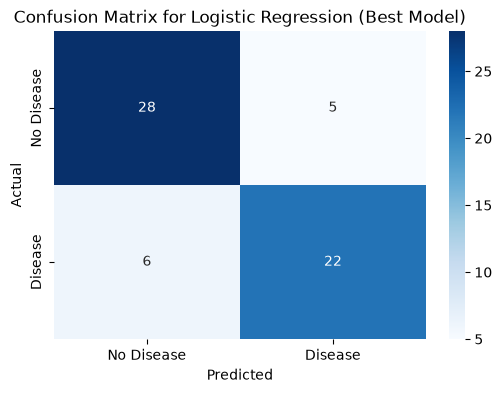

DETAILED TEXT REPORT
              precision    recall  f1-score   support

           0       0.82      0.85      0.84        33
           1       0.81      0.79      0.80        28

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [31]:
best_model_name = df_results.index[0]
best_model_pipeline = results[best_model_name]['Pipeline']

y_pred_best = best_model_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix for {best_model_name} (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


print("DETAILED TEXT REPORT")
print(classification_report(y_test, y_pred_best))

In [32]:
import joblib
joblib.dump(best_model_pipeline, 'best_heart_disease_model.pkl')
print("Model saved as 'best_heart_disease_model.pkl' successfully.")

Model saved as 'best_heart_disease_model.pkl' successfully.


In [ ]:
import pandas as pd
import joblib

# ── Load the saved model ──────────────────────────────────
model = joblib.load('best_heart_disease_model.pkl')

# ── High-risk test patient ────────────────────────────────
# Age 67, Male, Typical Angina, High BP, Elevated Cholesterol,
# Low Max HR, FBS elevated, LV Hypertrophy, Exercise Angina,
# High ST Depression, 3 vessels colored, Reversible Thal Defect
high_risk_patient = {
    "age":      67,
    "sex":       1,   # 1 = Male
    "cp":        0,   # 0 = Typical Angina
    "trestbps": 160,  # Resting BP (mm Hg)
    "chol":     295,  # Cholesterol (mg/dl)
    "fbs":       1,   # Fasting blood sugar > 120 mg/dl = True
    "restecg":   2,   # LV Hypertrophy
    "thalach":  108,  # Max heart rate achieved
    "exang":     1,   # Exercise induced angina = Yes
    "oldpeak":   3.4, # ST depression
    "slope":     0,   # Upsloping
    "ca":        3,   # 3 major vessels colored
    "thal":      3    # Reversible defect
}

# ── Run prediction ────────────────────────────────────────
df = pd.DataFrame([high_risk_patient])
prediction = model.predict(df)[0]
proba      = model.predict_proba(df)[0]

print(f"Prediction  : {'⚠ HIGH RISK — Heart Disease' if prediction == 1 else '✓ Low Risk — Normal'}")
print(f"Probability : Low Risk={proba[0]:.2%}  |  High Risk={proba[1]:.2%}")

Prediction  : ⚠ HIGH RISK — Heart Disease
Probability : Low Risk=0.76%  |  High Risk=99.24%


In [34]:
import pandas as pd
import joblib

# ── Load the saved model ──────────────────────────────────
model = joblib.load('best_heart_disease_model.pkl')

# ── Low-risk test patient ─────────────────────────────────
# Age 38, Female, Non-Anginal Pain, Normal BP, Normal Cholesterol,
# High Max HR, No FBS issue, Normal ECG, No Exercise Angina,
# Minimal ST Depression, 0 vessels colored, Normal Thal
low_risk_patient = {
    "age":      38,
    "sex":       0,   # 0 = Female
    "cp":        2,   # 2 = Non-Anginal Pain
    "trestbps": 110,  # Resting BP (mm Hg) — normal
    "chol":     180,  # Cholesterol (mg/dl) — healthy
    "fbs":       0,   # Fasting blood sugar <= 120 mg/dl = False
    "restecg":   1,   # Normal ECG
    "thalach":  172,  # Max heart rate achieved — high (good)
    "exang":     0,   # Exercise induced angina = No
    "oldpeak":   0.0, # ST depression — none
    "slope":     2,   # Upsloping — normal
    "ca":        0,   # 0 major vessels colored — clear
    "thal":      2    # Normal thal
}

# ── Run prediction ────────────────────────────────────────
patient_df = pd.DataFrame([low_risk_patient])
prediction = model.predict(patient_df)[0]
proba      = model.predict_proba(patient_df)[0]

print(f"Prediction  : {'⚠ HIGH RISK — Heart Disease' if prediction == 1 else '✓ Low Risk — Normal'}")
print(f"Probability : Low Risk={proba[0]:.2%}  |  High Risk={proba[1]:.2%}")

Prediction  : ✓ Low Risk — Normal
Probability : Low Risk=97.74%  |  High Risk=2.26%
